<a href="https://colab.research.google.com/github/hmurtaza720/Data-Science-Projects/blob/main/Iris_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Exploring and Visualizing the Iris Dataset

## Introduction & Problem Statement
The goal of this task is to understand how to load, inspect, and visualize a real-world dataset using Python libraries such as **pandas**, **matplotlib**, and **seaborn**.

The **Iris dataset** is one of the most well-known datasets in data science. It contains measurements of 150 iris flowers from 3 different species:
- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

Each sample has 4 features: sepal length, sepal width, petal length, and petal width (all in cm).

## Objectives
- Load and inspect the dataset structure
- Create scatter plots, histograms, and box plots
- Summarize key insights from the visualizations

## Step 1: Install & Import Required Libraries

In [1]:
# Install libraries if not already installed (uncomment if needed)
# !pip install pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better visuals
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load the Dataset

> **Dataset Source:** The Iris dataset is built into seaborn — no download required!

In [2]:
# Load the Iris dataset directly from seaborn
df = sns.load_dataset('iris')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')  # (rows, columns)

Dataset loaded successfully!
Shape: (150, 5)


## Step 3: Dataset Understanding & Description

In [3]:
# Display column names
print('Columns:', df.columns.tolist())
print()

# Display first 5 rows
print('First 5 rows:')
df.head()

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Data types and non-null counts
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# Count of each species
print('Species Value Counts:')
print(df['species'].value_counts())

# Check for missing values
print('\nMissing Values:')
print(df.isnull().sum())

Species Value Counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


## Step 4: Exploratory Data Analysis (EDA) with Visualizations

### 4.1 Scatter Plot — Relationships Between Variables

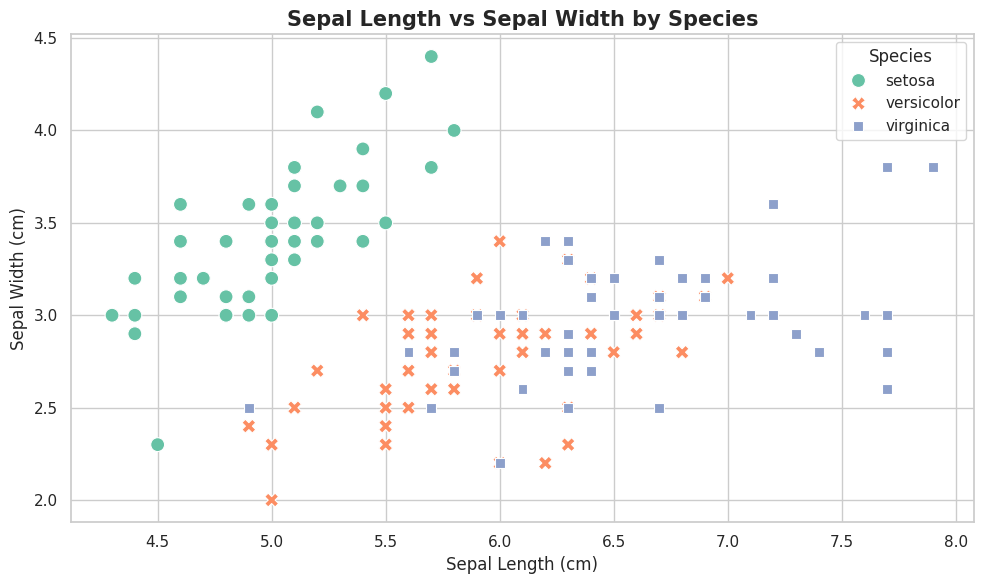

In [7]:
# Scatter plot: Sepal Length vs Sepal Width colored by species
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width',
                hue='species', style='species', s=100)
plt.title('Sepal Length vs Sepal Width by Species', fontsize=15, fontweight='bold')
plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.legend(title='Species')
plt.tight_layout()
plt.show()

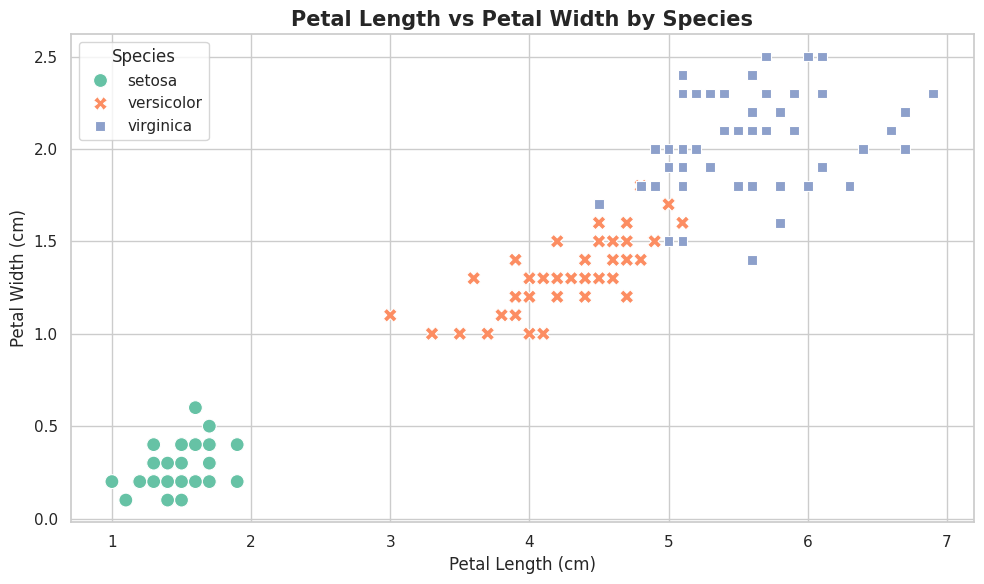

In [8]:
# Scatter plot: Petal Length vs Petal Width colored by species
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', style='species', s=100)
plt.title('Petal Length vs Petal Width by Species', fontsize=15, fontweight='bold')
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.legend(title='Species')
plt.tight_layout()
plt.show()

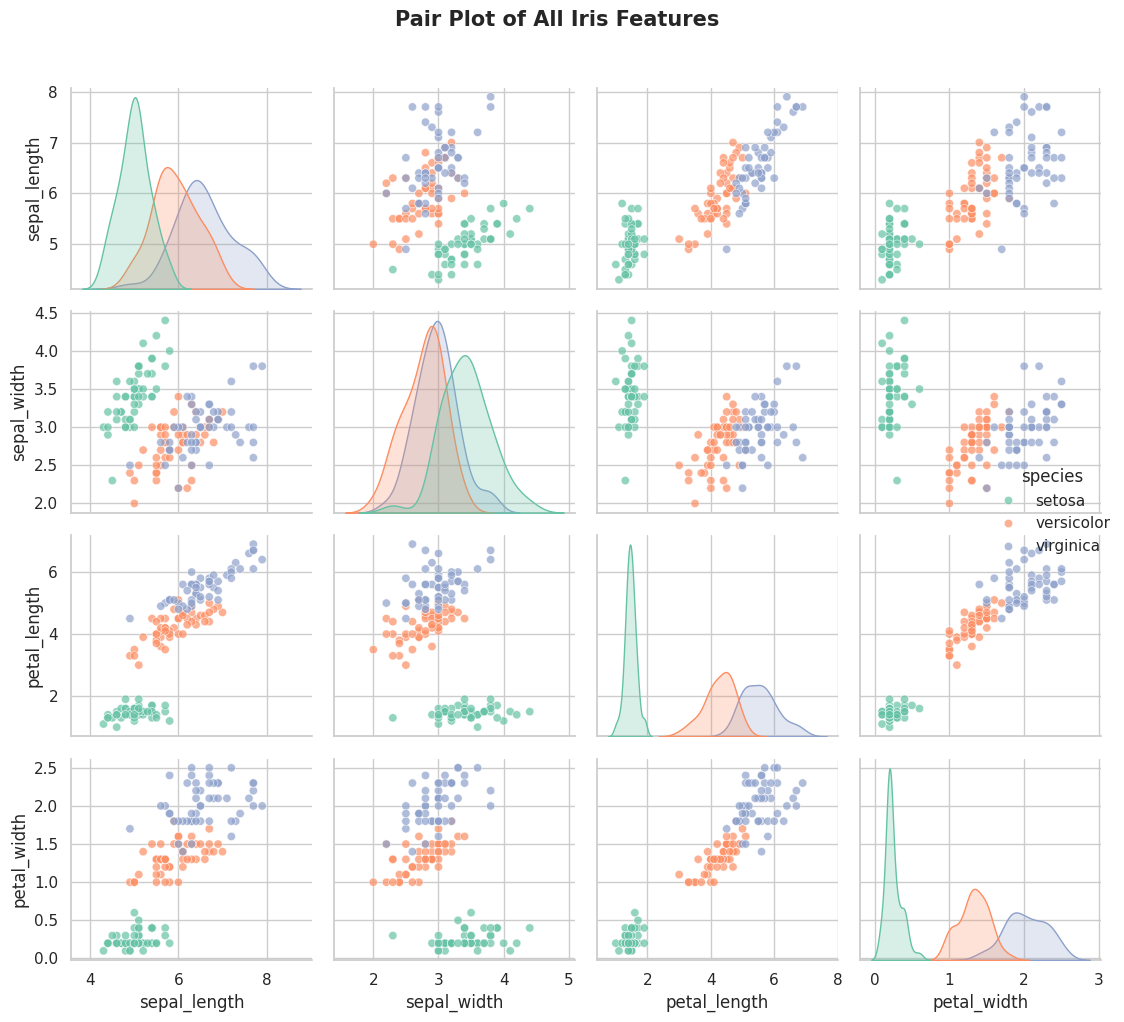

In [9]:
# Pair plot: All feature combinations
sns.pairplot(df, hue='species', diag_kind='kde', plot_kws={'alpha': 0.7})
plt.suptitle('Pair Plot of All Iris Features', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Histogram — Data Distribution

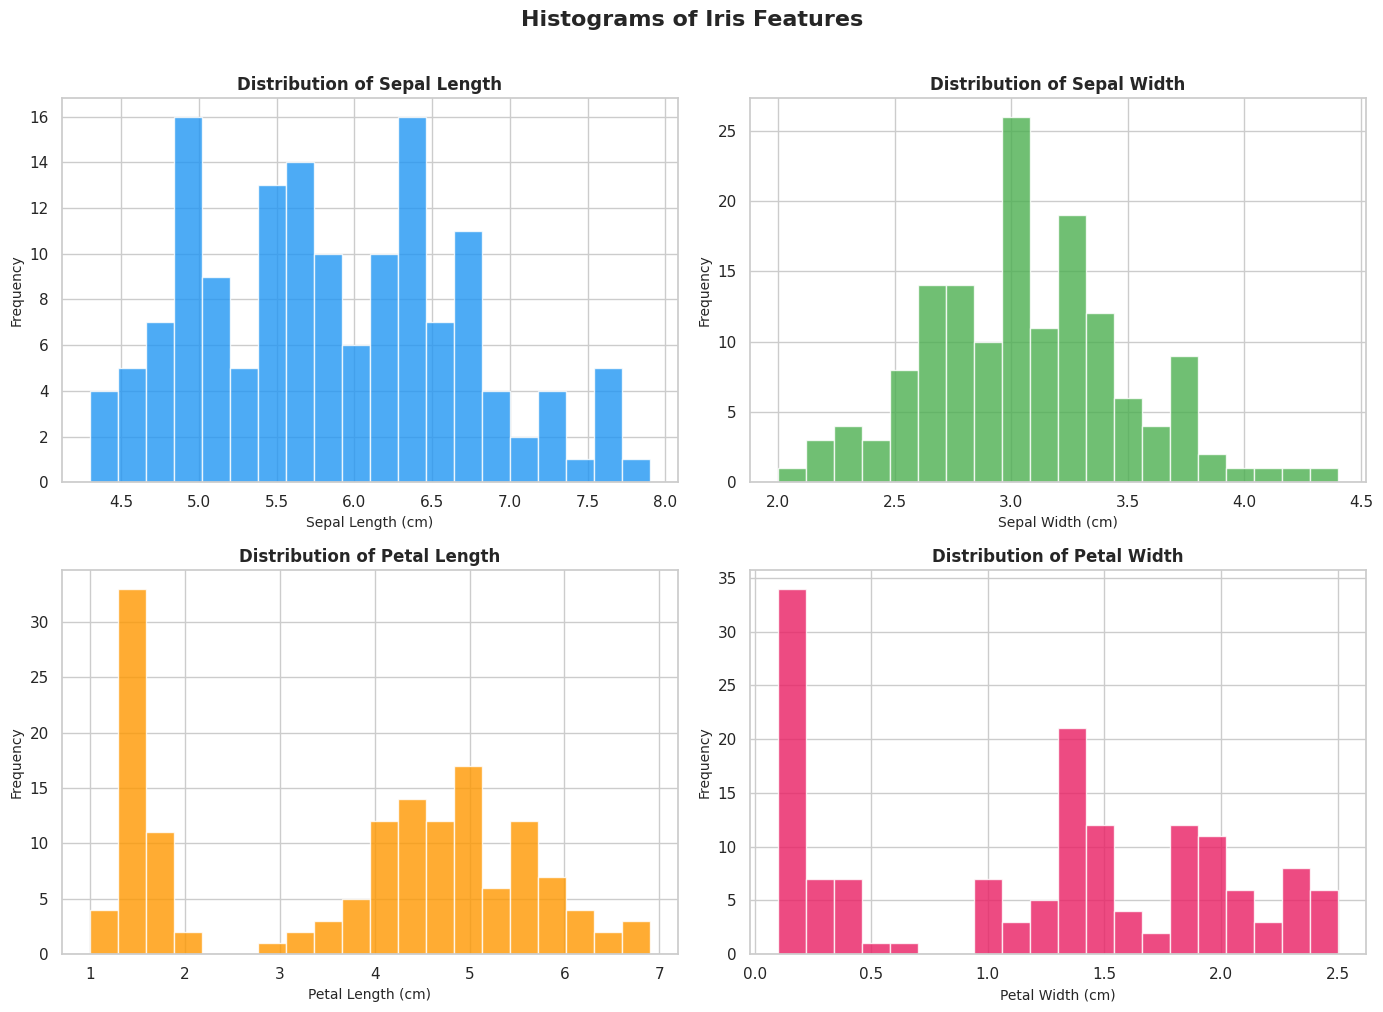

In [10]:
# Histogram for each numerical feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (feature, color) in enumerate(zip(features, colors)):
    row, col = i // 2, i % 2
    axes[row, col].hist(df[feature], bins=20, color=color, edgecolor='white', alpha=0.8)
    axes[row, col].set_title(f'Distribution of {feature.replace("_", " ").title()}',
                              fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel(f'{feature.replace("_", " ").title()} (cm)', fontsize=10)
    axes[row, col].set_ylabel('Frequency', fontsize=10)

plt.suptitle('Histograms of Iris Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

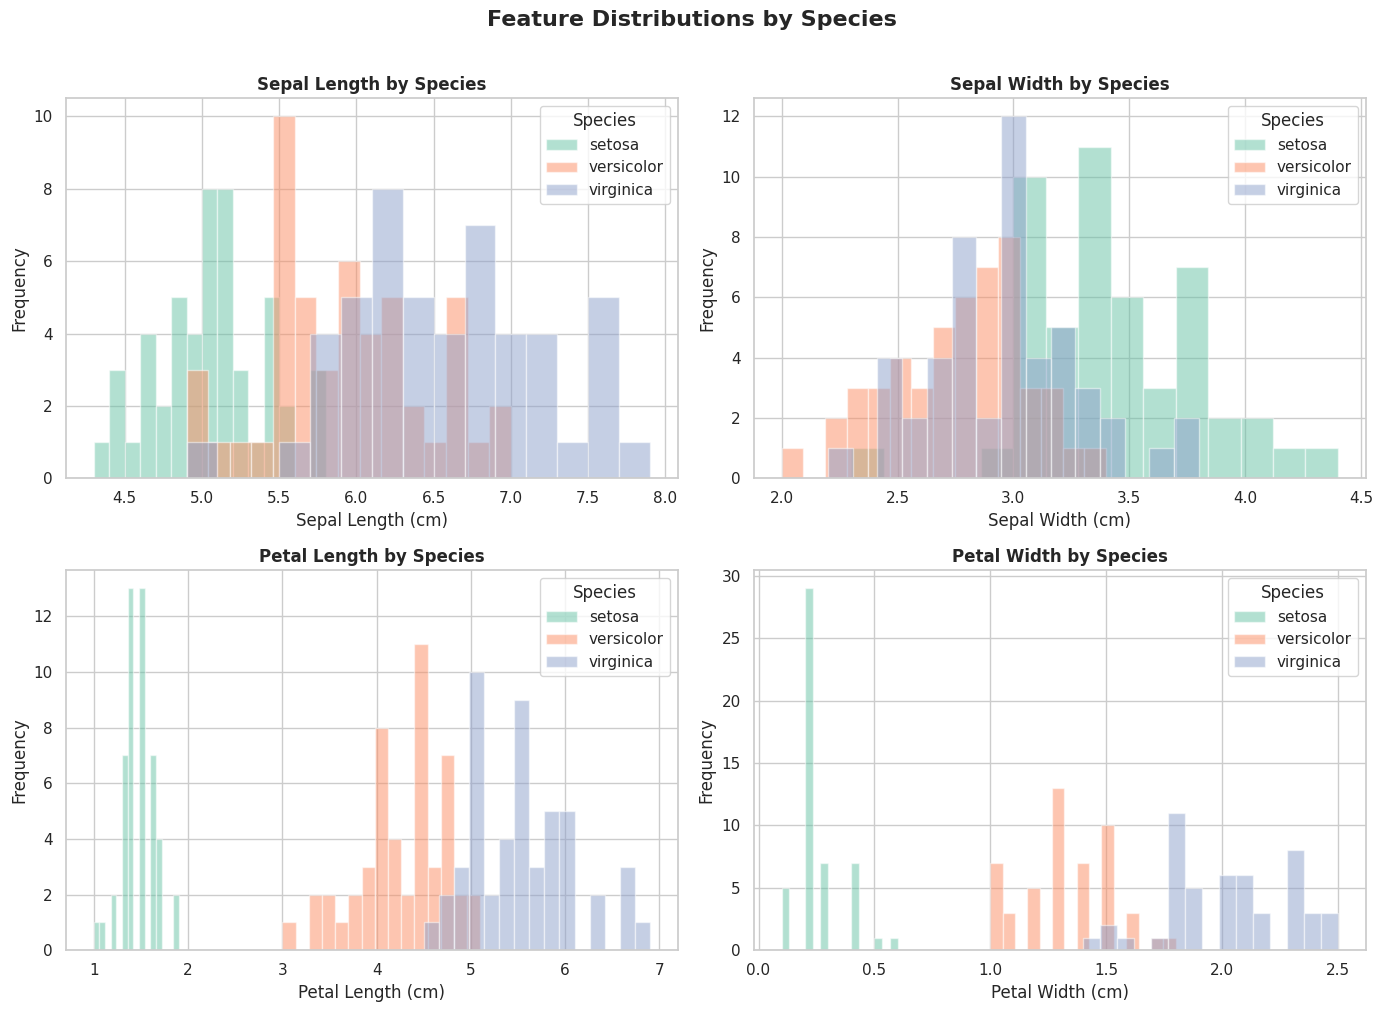

In [11]:
# KDE (Kernel Density) plots per species for each feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        axes[row, col].hist(subset[feature], bins=15, alpha=0.5, label=species, edgecolor='white')
    axes[row, col].set_title(f'{feature.replace("_", " ").title()} by Species',
                              fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel(f'{feature.replace("_", " ").title()} (cm)')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend(title='Species')

plt.suptitle('Feature Distributions by Species', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Box Plot — Outlier Detection & Spread

/tmp/ipykernel_14905/618575703.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col],
/tmp/ipykernel_14905/618575703.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col],
/tmp/ipykernel_14905/618575703.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col],
/tmp/ipykernel_14905/618575703.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 

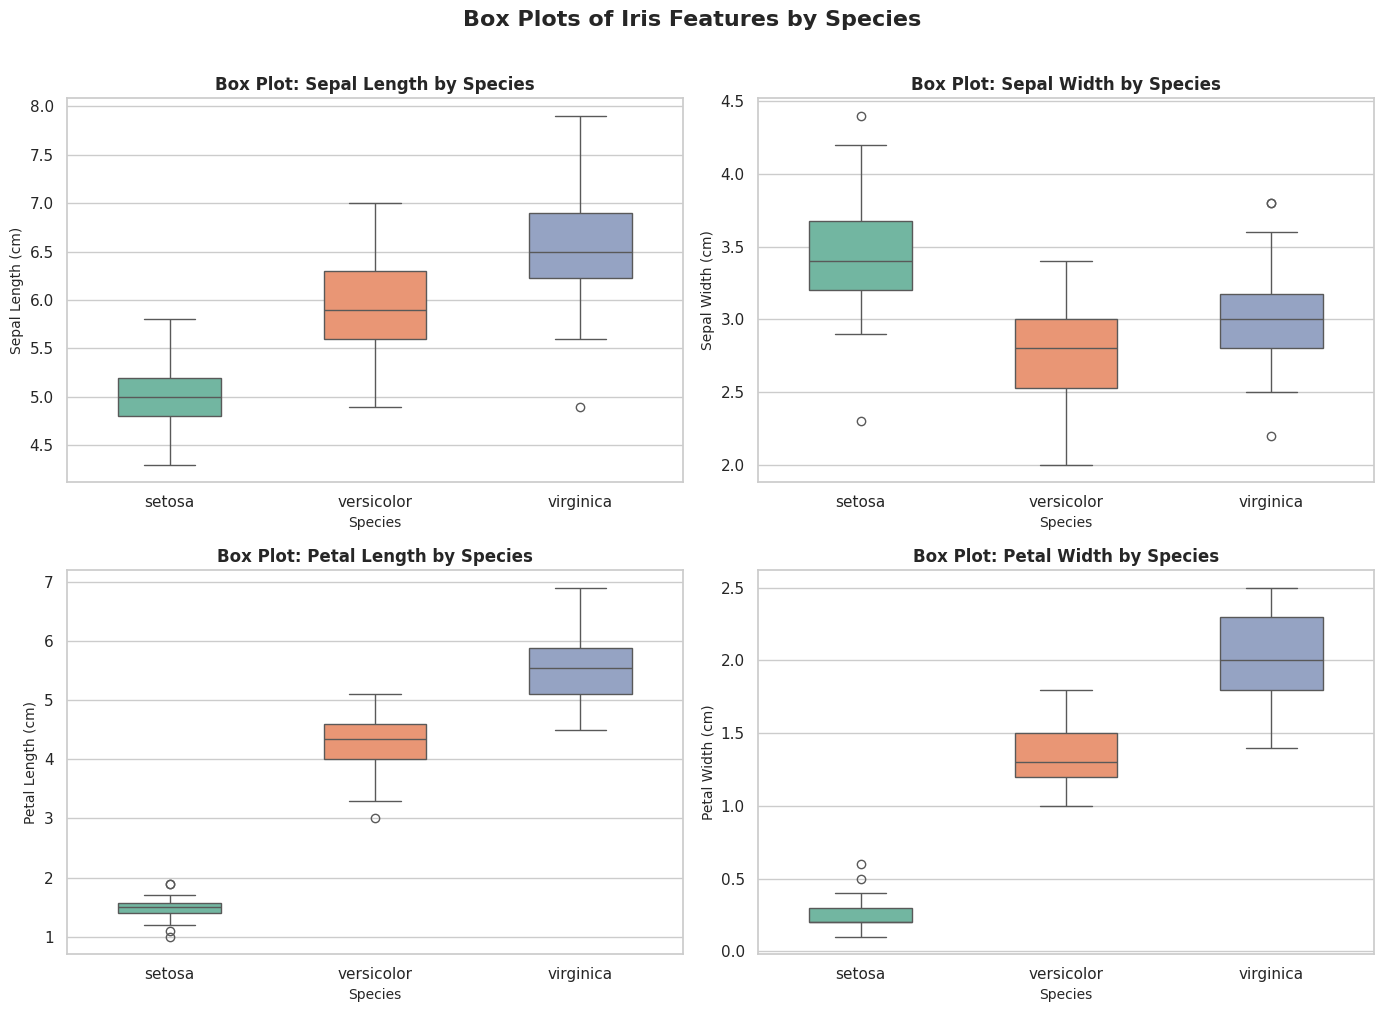

In [12]:
# Box plot for all features grouped by species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col],
                palette='Set2', width=0.5)
    axes[row, col].set_title(f'Box Plot: {feature.replace("_", " ").title()} by Species',
                              fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Species', fontsize=10)
    axes[row, col].set_ylabel(f'{feature.replace("_", " ").title()} (cm)', fontsize=10)

plt.suptitle('Box Plots of Iris Features by Species', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

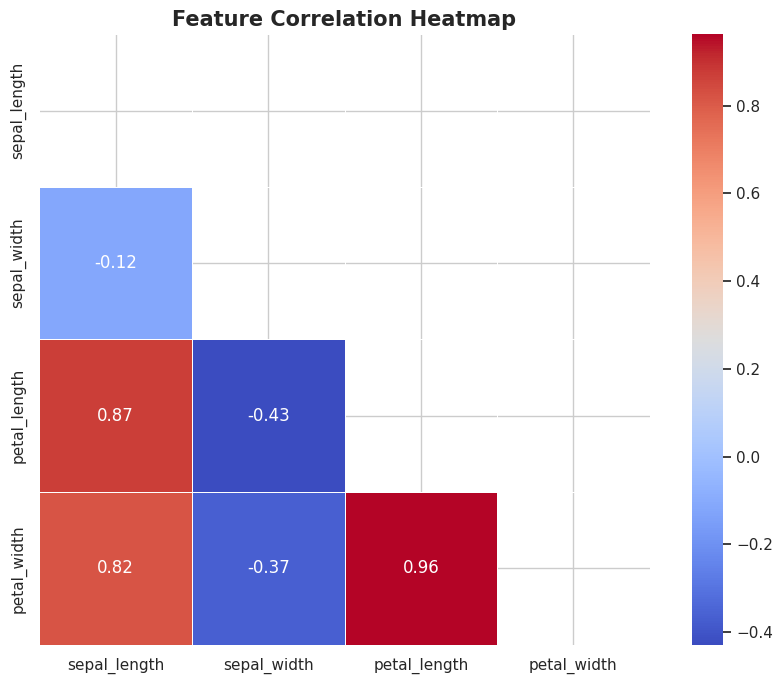

In [13]:
# Correlation Heatmap
plt.figure(figsize=(9, 7))
corr = df.drop('species', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Conclusion & Key Insights

From the analysis of the Iris dataset, we can draw the following insights:

1. **Species Separation**: *Iris setosa* is clearly separable from the other two species based on petal length and petal width. Versicolor and Virginica overlap slightly.

2. **Petal Features are More Discriminative**: Petal length and petal width show a stronger correlation (0.96) and are better at distinguishing species than sepal measurements.

3. **Outliers**: The box plots show minimal outliers. Sepal width has a few outliers in the setosa group.

4. **Distribution**: Petal length and petal width show a bimodal distribution (two peaks) because setosa is distinctly smaller than the other two species.

5. **Correlation**: Petal length and petal width are highly correlated, suggesting that a single petal measurement could be sufficient for classification.

These insights suggest that **petal dimensions** are the most useful features for classifying iris species.